In [33]:
import os , time, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from zipfile import ZipFile
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import scipy.stats as stats
import joblib, pickle
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [2]:
zip_path = "diabetes_binary_health_indicators_BRFSS2015.csv.zip"
extract_to = "./"

with ZipFile(zip_path, "r") as zip_ref:
    # Get metadata for all files in the zip
    for file_info in zip_ref.infolist():
        # Check for the specific file you want to rename
        if file_info.filename == "diabetes_binary_health_indicators_BRFSS2015.csv":
            # Change the filename in memory
            file_info.filename = "data.csv"
            # Extract only this file with its new name
            zip_ref.extract(file_info, path=extract_to)
            print("File extracted directly with the new name!")

File extracted directly with the new name!


In [3]:
# from sklearn.linear_model import  LogisticRegression , SGDClassifier , RidgeClassifier
# from sklearn.svm import SVC
# from sklearn.tree import DecisionTreeClassifier , ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier #, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.naive_bayes import GaussianNB
# import lightgbm as lgb
# from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split ,cross_val_score , GridSearchCV
from sklearn.metrics import classification_report , confusion_matrix, accuracy_score , precision_score , f1_score , recall_score

In [4]:
# models = {'Logistic Regression' : LogisticRegression(solver='lbfgs', max_iter=1000),
#         #   'SVM' : SVC(),
#           'Decision Tree' : DecisionTreeClassifier(),
#           'Random Forest' : RandomForestClassifier(),
#           'AdaBoost' : AdaBoostClassifier(algorithm='SAMME'),
#           'Bagging' : BaggingClassifier(),
#           'Gradient Boosting' : GradientBoostingClassifier(),
#           'Naive Bayes' : GaussianNB(),
#           'SGD' : SGDClassifier(),
#           'Ridge' : RidgeClassifier(),
#           'ExtraTrees' : ExtraTreeClassifier(),
#           'XGB' : XGBClassifier(),
#         #   'KNN' : KNeighborsClassifier(n_neighbors=5),
#         #   'LGB' : lgb
#           }

In [5]:
df = pd.read_csv("data.csv")

In [6]:
df.Diabetes_binary.value_counts()

Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

In [62]:
df.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [7]:
# from imblearn.under_sampling import RandomUnderSampler
# smt = RandomUnderSampler(random_state=42)
# X , y = smt.fit_resample(X, y)

In [8]:
# Dropping outliers
lower_limit = np.quantile(df['BMI'], 0.25)
upper_limit = np.quantile(df['BMI'], 0.75)
outlier_index = df[(df['BMI'] < lower_limit) | (df['BMI'] > upper_limit)].index
df.drop(outlier_index, inplace=True)

In [9]:
df.shape

(140147, 22)

In [10]:
target = "Diabetes_binary"
X = df.drop(target, axis=1)
y = df[target]

In [11]:
# def model_selection(model:dict, X_train, y_train, X_test, y_test):
#     """
#     Tests each model in the models dict against the training data and test data
#     and provides its accuracy score
#     :param model: dictionary of the models
#     :param X_train: Training data
#     :param y_train: Training labels
#     :param X_test: Test data
#     :param y_test: Test labels
#     :return: Accuracy score
#     """
#     a = []
#     p = []
#     f = []
#     r = []

#     for name, model in model.items():
#         model.fit(X_train, y_train.values.ravel())
#         y_pred = model.predict(X_test)
#         accuracy = accuracy_score(y_test, y_pred)
#         precision = precision_score(y_test, y_pred)
#         f1 = f1_score(y_test, y_pred)
#         recall = recall_score(y_test, y_pred)
#         a.append(accuracy) , p.append(precision) , f.append(f1) , r.append(recall)
#         print('Accuracy score for {}: {}'.format(name, accuracy))
#     names = list(models.keys())
#     results = pd.DataFrame({'Model_Name':names , 'Accuracy':a , 'Precison':p , 'F1 score': f , 'Recall':r})
#     return results.sort_values('Accuracy', ascending= False, ignore_index=True)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
scaler = StandardScaler()
col_trans = ColumnTransformer(transformers=[('scaler', scaler, ['BMI'])], remainder='passthrough')
X_train = col_trans.fit_transform(X_train)
X_test = col_trans.transform(X_test)
# results = model_selection(models, X_train, y_train, X_test, y_test)

### Cross validation

In [13]:
clf = RandomForestClassifier(random_state=42, class_weight="balanced")
scores = cross_val_score(clf, X, y, cv=5)
scores

array([0.83699608, 0.83303603, 0.83927361, 0.83253059, 0.83256627])

In [14]:
print("{} accuracy with a standard deviation of {}".format
      (scores.mean(), scores.std()))

0.8348805163786903 accuracy with a standard deviation of 0.0027587986233781514


### Hyperparameter tuning

In [15]:
param_grid = {
    'n_estimators': [50 ,100 , 200],
    'max_depth': [None, 5, 10, 20],
    "min_samples_leaf" : [1, 2, 4],
}

In [16]:
grid_search = GridSearchCV(clf,
                           param_grid=param_grid , cv=5, verbose=3, n_jobs=-1)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}


### {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}

#### Results of Hyperparameter tuning
{'max_depth': 20, 'min_samples_leaf': 4, 'n_estimators': 100}

### Final parameters for Random Forest

In [17]:
%%timeit

clf = RandomForestClassifier(max_depth=None, min_samples_leaf=1, n_estimators=100, class_weight="balanced", random_state=42)
clf.fit(X_train, y_train)


6.42 s ± 165 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [109]:
clf = RandomForestClassifier(
    max_depth=None, min_samples_leaf=1, n_estimators=100, class_weight="balanced", random_state=42
)
clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [110]:
y_pred = clf.predict(X_test)
print("accuracy_score: ", accuracy_score(y_test, y_pred))
print("precision_score: ", precision_score(y_test, y_pred))
print("f1_score: ", f1_score(y_test, y_pred))
print("recall_score: ", recall_score(y_test, y_pred))

accuracy_score:  0.8319657509810917
precision_score:  0.30797720797720796
f1_score:  0.31461001164144353
recall_score:  0.3215348007138608


In [111]:
joblib.dump(clf,"sklearn_rf.joblib")

['sklearn_rf.joblib']

In [112]:
## Model Size
model_size = os.path.getsize("sklearn_rf.joblib")
print("Model size:", model_size/(1024*1024), "mb")

Model size: 329.85234928131104 mb


In [113]:
## feaure importance
feature_names = [f"{i}" for i in X.columns]
importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=feature_names)
forest_importances.sort_values(ascending=False, inplace=True)
forest_importances[:10]

Age          0.146686
HighBP       0.113320
GenHlth      0.108773
Income       0.093964
PhysHlth     0.075738
HighChol     0.066511
Education    0.064653
MentHlth     0.056896
CholCheck    0.038544
Smoker       0.032978
dtype: float64

In [114]:
# Randomizing the data with X , y split
rf_results = pd.DataFrame(columns=['Accuracy', 'Precision', 'F1 Score', 'Recall', 'Model Size', 'Time'])
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i)
    scaler = StandardScaler()
    col_trans = ColumnTransformer(
        transformers=[('scaler', scaler, ['BMI'])], remainder='passthrough')
    X_train = col_trans.fit_transform(X_train)
    X_test = col_trans.transform(X_test)
    start = time.time()
    clf = RandomForestClassifier(
        max_depth=None, min_samples_leaf=1, n_estimators=100, random_state=42
    )
    clf.fit(X_train, y_train)
    stop = time.time()

    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    model_bytes = pickle.dumps(clf)
    model_size = sys.getsizeof(model_bytes) / (1024 * 1024)
    time_taken = stop - start
    rf_results.loc[i] = [accuracy, precision, f1, recall, model_size, time_taken]
rf_results

,Accuracy,Precision,F1 Score,Recall,Model Size,Time
0,0.875419,0.375196,0.120403,0.071707,291.560771,6.424394
1,0.873992,0.357250,0.119202,0.071535,291.386210,6.187846
2,0.877096,0.378582,0.127185,0.076431,292.539775,6.142563
3,0.878380,0.361734,0.124326,0.075062,292.838695,14.987245
4,0.873172,0.351471,0.118522,0.071279,291.134288,21.687386
5,0.873992,0.372881,0.120518,0.071874,291.519420,19.109881
6,0.874599,0.394984,0.125404,0.074534,291.725718,18.520390
7,0.877988,0.343239,0.119011,0.071985,293.744456,15.191783
8,0.876775,0.376453,0.130413,0.078867,292.848460,6.791547
9,0.873742,0.365706,0.119871,0.071684,291.593272,6.955885


In [115]:
rf_results.describe().T.round(5)

,count,mean,std,min,25%,50%,75%,max
Accuracy,10.0,0.87552,0.00190,0.87317,0.87399,0.87501,0.87702,0.87838
Precision,10.0,0.36775,0.01503,0.34324,0.35837,0.36929,0.37614,0.39498
F1 Score,10.0,0.12249,0.00409,0.11852,0.11937,0.12046,0.12513,0.13041
Recall,10.0,0.07350,0.00261,0.07128,0.07169,0.07193,0.07493,0.07887
Model Size,10.0,292.08911,0.84781,291.13429,291.52976,291.65950,292.76396,293.74446
Time,10.0,12.19989,6.30143,6.14256,6.51618,10.97157,17.68824,21.68739


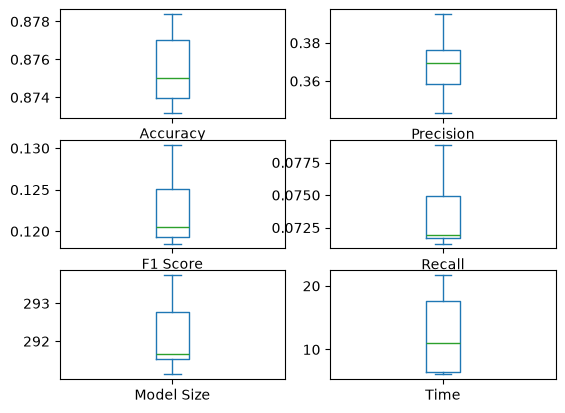

In [116]:
rf_results.plot(kind='box', subplots=True, layout=(3, 2) , sharex=False, sharey=False)
plt.show()

# YDF

In [117]:
import ydf

In [118]:
df['Diabetes_binary'] = df['Diabetes_binary'].astype('Int16')

In [119]:
train_df = pd.DataFrame(
    np.column_stack((X_train, y_train)), columns=(list(X.columns) + [y.name])
)
test_df = pd.DataFrame(
    np.column_stack((X_test,y_test)), columns=(list(X.columns) + [y.name])
)

In [136]:
train_df["Diabetes_binary"] = train_df.Diabetes_binary.astype("int16")
test_df["Diabetes_binary"] = test_df.Diabetes_binary.astype("int16")

In [142]:
# Calculate balanced weights manually
# Formula: total_samples / (num_classes * class_samples)
total_samples_train = len(train_df)
class_counts_train = train_df[target].value_counts()
num_classes_train = len(class_counts_train)

balanced_weights_train = {
    cls: total_samples_train / (num_classes_train * count) for cls, count in class_counts_train.items()
}


total_samples_test = len(test_df)
class_counts_test = test_df[target].value_counts()
num_classes_test = len(class_counts_test)

balanced_weights_test = {
    cls: total_samples_test / (num_classes_test * count)
    for cls, count in class_counts_test.items()
}

In [143]:
train_df_weighted = train_df.copy()
train_df_weighted["sample_weight"] = train_df_weighted["Diabetes_binary"].map(
    balanced_weights_train
)
test_df_weighted = test_df.copy()
test_df_weighted["sample_weight"] = test_df_weighted["Diabetes_binary"].map(
    balanced_weights_test
)

In [144]:

model = ydf.RandomForestLearner(
    label="Diabetes_binary", weights="sample_weight"
).train(train_df_weighted)


Train model on 112117 examples
Model trained in 0:00:07.009693


In [145]:
model.describe()

In [146]:
model.evaluate(test_df_weighted)

Label \ Pred,0,1
0,18319,1027
1,6349,2335


In [147]:
model.analyze(test_df_weighted)

## Cross Validation of YDF

In [148]:
learner = ydf.RandomForestLearner(label='Diabetes_binary')
evaluation = learner.cross_validation(df, folds=5)

evaluation

Label \ Pred,0,1
0,123141,16139
1,411,456


In [149]:
templates = ydf.RandomForestLearner.hyperparameter_templates()
templates

{'better_defaultv1': HyperparameterTemplate(name='better_default', version=1, parameters={'winner_take_all': True}, description='A configuration that is generally better than the default parameters without being more expensive.'),
 'benchmark_rank1v1': HyperparameterTemplate(name='benchmark_rank1', version=1, parameters={'winner_take_all': True, 'categorical_algorithm': 'RANDOM', 'split_axis': 'SPARSE_OBLIQUE', 'sparse_oblique_normalization': 'MIN_MAX', 'sparse_oblique_num_projections_exponent': 1.0}, description='Top ranking hyper-parameters on our benchmark slightly modified to run in reasonable time.')}

In [151]:
better_defaultv1 = templates["better_defaultv1"]
learner = ydf.RandomForestLearner(
    "Diabetes_binary", weights="sample_weight", ** better_defaultv1
).train(train_df_weighted)

Train model on 112117 examples
Model trained in 0:00:10.574870


In [152]:
learner.evaluate(test_df_weighted)

Label \ Pred,0,1
0,18319,1027
1,6349,2335


In [153]:
benchmark_rank1v1 = templates["benchmark_rank1v1"]
learner = ydf.RandomForestLearner(
    "Diabetes_binary", weights="sample_weight", ** benchmark_rank1v1
).train(train_df_weighted)
learner.evaluate(test_df_weighted)

Train model on 112117 examples
Model trained in 0:00:32.645603


Label \ Pred,0,1
0,18010,938
1,6658,2424


### Final parameters for YDF

In [154]:
learner = ydf.RandomForestLearner(
    "Diabetes_binary", weights="sample_weight", ** benchmark_rank1v1
).train(train_df_weighted)
evaluation = learner.evaluate(test_df_weighted)

Train model on 112117 examples
Model trained in 0:00:33.832123


In [155]:
print(evaluation)

accuracy: 0.729005
confusion matrix:
    label (row) \ prediction (col)
    +-------+-------+-------+
    |       |     0 |     1 |
    +-------+-------+-------+
    |     0 | 18010 |  6658 |
    +-------+-------+-------+
    |     1 |   938 |  2424 |
    +-------+-------+-------+
characteristics:
    name: '1' vs others
    ROC AUC: 0.792708
    PR AUC: 0.301789
    Num thresholds: 302
loss: 0.599528
num examples: 28030
num examples (weighted): 28030



In [156]:
evaluation.accuracy

np.float64(0.7290046378879772)

In [73]:
# Precision
precision = evaluation.confusion_matrix.matrix[0][0] / (evaluation.confusion_matrix.matrix[0][0] + evaluation.confusion_matrix.matrix[0][1])
print("Precision: ", precision)
# Recall
recall = evaluation.confusion_matrix.matrix[0][0] / (evaluation.confusion_matrix.matrix[0][0] + evaluation.confusion_matrix.matrix[1][0])
print("Recall: ", recall)
# F1 Score
f1 = 2 * (precision * recall) / (precision + recall)
print("F1 Score: ", f1)

Precision:  0.9933305274063522
Recall:  0.8863498483316481
F1 Score:  0.9367958230283046


In [61]:
learner.describe()

In [66]:
sys.getsizeof(learner)

56

In [67]:
# Randomizing the data with X , y split
gb_results = pd.DataFrame(columns=['Accuracy', 'Precision', 'F1 Score', 'Recall', 'Model Size', 'Time'])
for i in range(10):
    train_ds, test_ds = train_test_split(df, random_state=i)
    benchmark_rank1v1 = templates["benchmark_rank1v1"]
    start = time.time()
    learner = ydf.GradientBoostedTreesLearner(
        'Diabetes_binary', **benchmark_rank1v1).train(train_ds)
    stop = time.time()
    evaluation = learner.evaluate(test_ds)
    accuracy = evaluation.accuracy
    precision = evaluation.confusion_matrix.matrix[0][0] / (
        evaluation.confusion_matrix.matrix[0][0] + evaluation.confusion_matrix.matrix[0][1])
    recall = evaluation.confusion_matrix.matrix[0][0] / (
        evaluation.confusion_matrix.matrix[0][0] + evaluation.confusion_matrix.matrix[1][0])
    f1 = 2 * (precision * recall) / (precision + recall)
    model_size = sys.getsizeof(learner)
    time_taken = stop - start
    gb_results.loc[i] = [accuracy, precision, f1, recall, model_size, time_taken]
gb_results

Train model on 105110 examples
Model trained in 0:00:05.923095
Train model on 105110 examples
Model trained in 0:00:08.231475
Train model on 105110 examples
Model trained in 0:00:06.729176
Train model on 105110 examples
Model trained in 0:00:07.855705
Train model on 105110 examples
Model trained in 0:00:14.752498
Train model on 105110 examples
Model trained in 0:00:11.958791
Train model on 105110 examples
Model trained in 0:00:33.248901
Train model on 105110 examples
Model trained in 0:00:11.138727
Train model on 105110 examples
Model trained in 0:00:07.167337
Train model on 105110 examples
Model trained in 0:00:09.802882


,Accuracy,Precision,F1 Score,Recall,Model Size,Time
0,0.882838,0.996438,0.937472,0.885095,56.0,5.950940
1,0.880555,0.994875,0.936139,0.883951,56.0,8.268454
2,0.884379,0.994669,0.938270,0.887924,56.0,6.761293
3,0.883923,0.993669,0.937996,0.888231,56.0,7.884521
4,0.879213,0.992701,0.935328,0.884224,56.0,14.787836
5,0.880612,0.993484,0.936117,0.885013,56.0,11.997255
6,0.881554,0.995332,0.936703,0.884597,56.0,33.321762
7,0.885093,0.993458,0.938703,0.889668,56.0,11.159113
8,0.881925,0.994467,0.936947,0.885716,56.0,7.216581
9,0.881839,0.993331,0.936796,0.886350,56.0,9.823912


In [87]:
gb_results.describe().T.round(5)

,count,mean,std,min,25%,50%,75%,max
Accuracy,10.0,0.88219,0.00186,0.87921,0.88085,0.88188,0.88365,0.88509
Precision,10.0,0.99424,0.00112,0.99270,0.99346,0.99407,0.99482,0.99644
F1 Score,10.0,0.93705,0.00106,0.93533,0.93628,0.93687,0.93787,0.93870
Recall,10.0,0.88608,0.00193,0.88395,0.88470,0.88541,0.88753,0.88967
Model Size,10.0,56.00000,0.00000,56.00000,56.00000,56.00000,56.00000,56.00000
Time,10.0,11.71717,8.06095,5.95094,7.38357,9.04618,11.78772,33.32176


In [84]:
## Significance Testing with Pingouin
for i in rf_results.columns:
    print(i)
    print(stats.ttest_ind(rf_results[i], gb_results[i]))
    print("=="*50)

Accuracy
TtestResult(statistic=-0.23396495556032085, pvalue=0.8176525728315747, df=18.0)
Precision
TtestResult(statistic=-51.85938429255839, pvalue=4.7213391174950035e-21, df=18.0)
F1 Score
TtestResult(statistic=-592.14387590922, pvalue=4.590358517100128e-40, df=18.0)
Recall
TtestResult(statistic=-845.8688413698204, pvalue=7.484790863717256e-43, df=18.0)
Model Size
TtestResult(statistic=nan, pvalue=nan, df=18.0)
Time
TtestResult(statistic=-2.6465490001116354, pvalue=0.016408091752808836, df=18.0)
